## Auto_Correlation Analysis of 2D Square Lattice Ferromagnetic Ising Model

In [1]:
include("../src/lattice.jl")
include("../src/metropolis_ising.jl")
using .UnitCell_Lattices
using .Metropolis_MonteCarlo

using Plots
using StatsBase
using StatsPlots

In [2]:
J = [1.,1.,1.]
a = 1.0
h = 0.0
L = [32,32]
T = 0.2:0.2:3.0

0.2:0.2:3.0

In [ ]:
a = [3/2 3/2;
     sqrt(3)/2 -sqrt(3)/2] # Lattice vectors for a triangular lattice

b = [0.0 1.0;
     0.0 0.0]

#B = reshape(B, (2,1))
     
uc_honeycomb = UnitCell(a,b)
rules_honeycomb = [BondRule(1,2,[0,0]),BondRule(1,2,[-1,0]),BondRule(1,2,[0,-1])]
honeycomb_lattice = build_lattice(uc_honeycomb, rules_honeycomb, L)

Lattice(UnitCell([1.5 1.5; 0.8660254037844386 -0.8660254037844386], [0.0 1.0; 0.0 0.0]), BondRule[BondRule(1, 2, [0, 0]), BondRule(1, 2, [-1, 0]), BondRule(1, 2, [0, -1])], [32, 32], Site[Site(1, [0, 0], 1, [0.0, 0.0], [0.0, 0.0, 0.0]), Site(2, [0, 0], 2, [1.0, 0.0], [0.0, 0.0, 0.0]), Site(3, [1, 0], 1, [1.5, 0.8660254037844386], [0.0, 0.0, 0.0]), Site(4, [1, 0], 2, [2.5, 0.8660254037844386], [0.0, 0.0, 0.0]), Site(5, [2, 0], 1, [3.0, 1.7320508075688772], [0.0, 0.0, 0.0]), Site(6, [2, 0], 2, [4.0, 1.7320508075688772], [0.0, 0.0, 0.0]), Site(7, [3, 0], 1, [4.5, 2.598076211353316], [0.0, 0.0, 0.0]), Site(8, [3, 0], 2, [5.5, 2.598076211353316], [0.0, 0.0, 0.0]), Site(9, [4, 0], 1, [6.0, 3.4641016151377544], [0.0, 0.0, 0.0]), Site(10, [4, 0], 2, [7.0, 3.4641016151377544], [0.0, 0.0, 0.0])  …  Site(2039, [27, 31], 1, [87.0, -3.464101615137756], [0.0, 0.0, 0.0]), Site(2040, [27, 31], 2, [88.0, -3.464101615137756], [0.0, 0.0, 0.0]), Site(2041, [28, 31], 1, [88.5, -2.598076211353315], [0.0, 0.

In [4]:
data_22 = []
data_eq = []
data_29 = []
for Temp in [2.2, 2.269, 2.9]
    for n in 1:1
        lat = build_lattice(uc_honeycomb, rules_honeycomb, L)
        for site in lat.sites
            site.spin = [0, 0, rand(-1:2:1)]
        end
        res = monte_carlo_simulation(lat, Temp, J, h, 1000000, 5000, 200)
        if Temp == 2.2
            push!(data_22, res)
        elseif Temp == 2.269
            push!(data_eq, res)
        else
            push!(data_29, res)
        end
    end
end

In [5]:
function autocorrelation(Q::Vector{Float64}, max_lag::Int)
    N = length(Q)
    Q_mean = mean(Q)
    Q_var = mean((Q .- Q_mean).^2)

    A = zeros(Float64,max_lag+1)
    for t in 0:max_lag
        s = 0
        c = N-t
        for i in 1:c
            s += Q[i+t]*Q[i]
        end
        mean_s = s/c
        A[t+1] = (mean_s - Q_mean^2)/Q_var
    end 
    return A
end

autocorrelation (generic function with 1 method)

In [6]:
m_22 = Float64[]
e_22 = Float64[]
m_sq_22 = Float64[]
for i in 1:length(data_22)
    append!(m_22,data_22[i][2])
    append!(e_22,data_22[i][1])
    append!(m_sq_22,data_22[i][3])
end

m_eq = Float64[]
e_eq = Float64[]
m_sq_eq = Float64[]
for i in 1:length(data_eq)
    append!(m_eq,data_eq[i][2])
    append!(e_eq,data_eq[i][1])
    append!(m_sq_eq,data_eq[i][3])
end

m_29 = Float64[]
e_29 = Float64[]
m_sq_29 = Float64[]
for i in 1:length(data_29)
    append!(m_29,data_29[i][2])
    append!(e_29,data_29[i][1])
    append!(m_sq_29,data_29[i][3])
end


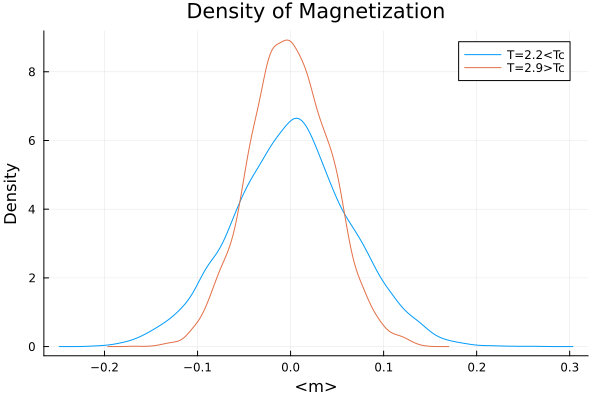

In [7]:
density(m_22,label="T=2.2<Tc",title="Density of Magnetization",xlabel="<m>",ylabel="Density")
density!(m_29,label="T=2.9>Tc")

In [8]:
max_lag = 500
A_m22 = autocorrelation(m_22,max_lag)
A_m29 = autocorrelation(m_29,max_lag)
A_meq = autocorrelation(m_eq,max_lag)

A_e22 = autocorrelation(e_22,max_lag)
A_e29 = autocorrelation(e_29,max_lag)
A_eeq = autocorrelation(e_eq,max_lag)

A_msq22 = autocorrelation(m_sq_22,max_lag)
A_msq29 = autocorrelation(m_sq_29,max_lag)
A_msqeq = autocorrelation(m_sq_eq,max_lag)

501-element Vector{Float64}:
  0.9999999999999999
 -0.003337214506535807
 -0.017514175614955087
 -0.00405913925797442
 -0.0051568797387400575
  0.015127701951665448
  0.011468599041689453
 -0.0027212817502804366
  0.014833359777933324
 -0.01825315368000192
 -0.003135679301894176
 -0.012770606999890995
 -0.01077558539456433
  ⋮
 -0.010588486183861821
  0.019163356005182822
  0.004645817918228543
 -0.012133842048404243
  0.001155077808740606
 -0.002214982647457631
  0.014784056541852214
 -0.011768900155394753
 -0.0030362803501167335
 -0.013394340231967295
 -0.013754881892003896
 -0.0012167848877859748

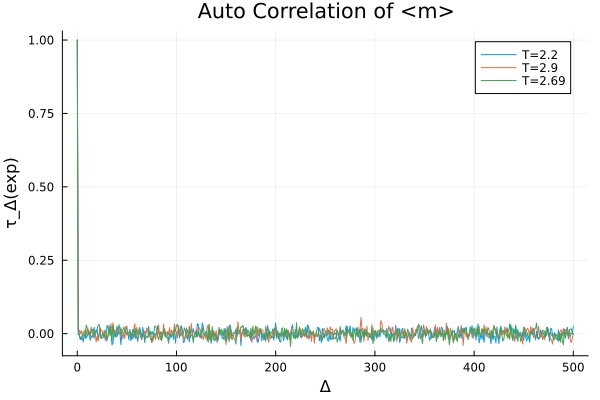

In [9]:

auto_cor_plot = plot(0:max_lag,A_m22,xlabel="Δ",ylabel="τ_Δ(exp)",title="Auto Correlation of <m>",label="T=2.2")
plot!(auto_cor_plot,0:max_lag,A_m29, label="T=2.9")
plot!(auto_cor_plot,0:max_lag,A_meq, label="T=2.69")

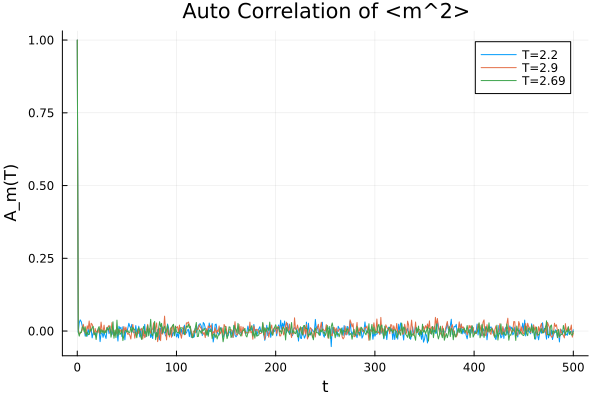

In [10]:
auto_cor_plot = plot(0:max_lag,A_msq22,xlabel="t",ylabel="A_m(T)",label="T=2.2",title="Auto Correlation of <m^2>")
plot!(auto_cor_plot,0:max_lag,A_msq29, label="T=2.9")
plot!(auto_cor_plot,0:max_lag,A_msqeq, label="T=2.69")

In [11]:
## correlation time
using LsqFit
A = A_meq
auto_correlation_model(t,p) = p[1].*exp.(-t./p[2])
t = collect(0:length(A)-1)
mask = A.>0.05 #eliminate the non-zero values
fit = curve_fit(auto_correlation_model,t[mask],A[mask],[1.0,10.0])
A0, τ = fit.param
A0_pm, τ_pm = standard_errors(fit)


p = plot(t, A,xlabel="t", ylabel="A_m(t)", label="T=2.269")
plot!(p,t,auto_correlation_model(t,[A0,τ]),label="τ = $(round(τ,sigdigits=2)) ± $(round(τ_pm,sigdigits=2))")



LoadError: DimensionMismatch: matrix is not square: dimensions are (1, 2)

Q = 0.002037039516630037 ± 1.3616816346976283e-5


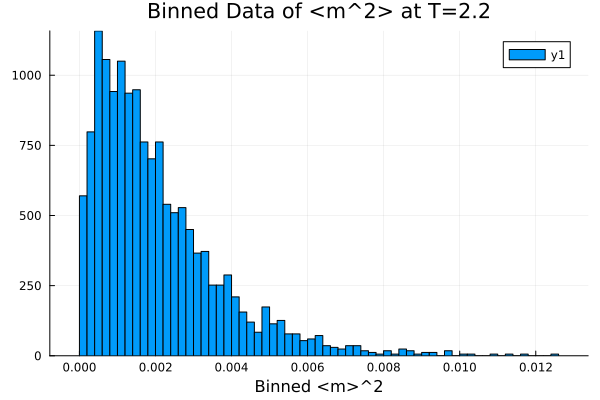

In [ ]:
#Binning Data to estimate the error of the mean
function binning_data(data::Vector{Float64},l::Int,bin_size::Int)
    data_binned = []

    n_data = copy(data)
    while l>0 
        for i in bin_size:bin_size:length(data)-bin_size
            push!(data_binned,data[i:i+bin_size]/bin_size)
        end
        n_data = data_binned
        l -= 1
    end

    B = length(data)
    B_data = []
    for i in 1:length(data_binned)
        mi = mean(data_binned[i])
        push!(B_data,mi)
    end

    B_mean = mean(B_data)
    B_std = sqrt(var(B_data)/(length(B_data)-1))
    
    return B_mean, B_std, B_data
end
    
Binned = binning_data(m_sq_22,6,2)
println("Q = $(Binned[1]) ± $(Binned[2])")
histogram(Binned[3],xlabel="Binned <m>^2",title="Binned Data of <m^2> at T=2.2")

Q = 0.004034509581904258 ± 7.776274453539932e-5


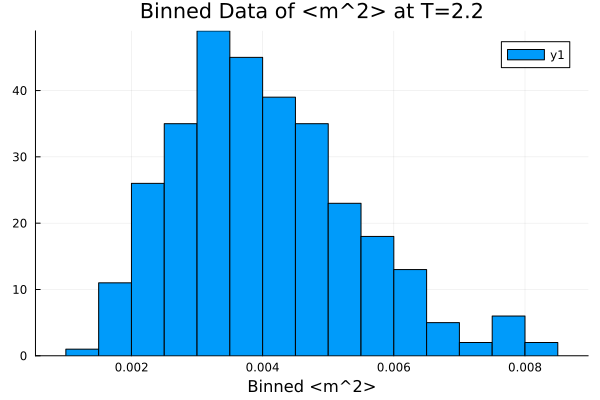

In [ ]:

function binning_data(data::Vector{Float64}, l::Int, bin_size::Int)
    l >= 0 || error("l must be nonnegative")
    bin_size > 0 || error("bin_size must be positive")

    n_data = copy(data)

    for _ in 1:l
        data_binned = Float64[]

        for i in 1:bin_size:(length(n_data) - bin_size + 1)
            push!(data_binned, mean(n_data[i:i+bin_size-1]))
        end

        n_data = data_binned
    end

    B = length(n_data)
    B >= 2 || error("Too few blocks; reduce l or bin_size")

    return mean(n_data), std(n_data) / sqrt(B), n_data
end

Binned = binning_data(m_sq_22,4,2)
println("Q = $(Binned[1]) ± $(Binned[2])")
histogram(Binned[3],xlabel="Binned <m^2>",title="Binned Data of <m^2> at T=2.2")

In [ ]:
for l in 1:8
    μ, se, blocks = binning_data(m_sq_22, l, 2)
    println("Block size=$(2^l), blocks=$(length(blocks)), mean=$μ, SE=$se")
end

Block size=2, blocks=2487, mean=0.004038719465610825, SE=7.965608481432281e-5
Block size=4, blocks=1243, mean=0.004040099686417767, SE=7.847792329643047e-5
Block size=8, blocks=621, mean=0.004038771953367765, SE=7.873371373287832e-5
Block size=16, blocks=310, mean=0.004034509581904258, SE=7.776274453539932e-5
Block size=32, blocks=155, mean=0.004034509581904258, SE=8.221410164607858e-5
Block size=64, blocks=77, mean=0.004032741506378372, SE=9.162143502238898e-5
Block size=128, blocks=38, mean=0.004030279030925349, SE=9.964033142068774e-5
Block size=256, blocks=19, mean=0.004030279030925349, SE=0.0001092493679396237


In [ ]:
μ, se, blocks = binning_data(m_sq_22, 16, 2)
std0 = std(m_sq_22)
println(std0)
τ = 0.5*(se/std0 - 1)

LoadError: Too few blocks; reduce l or bin_size

In [ ]:
data = m_sq_22
l = 8  # 2048 measurements per block

# Use the same observations for both error estimates
block_size = 2^l
n_used = (length(data) ÷ block_size) * block_size
used = data[1:n_used]

μ, se, blocks = binning_data(used, l, 2)
se0 = std(data) / sqrt(length(data))

τ_int = 0.5 * ((se / se0)^2 - 1)
println("τ_int = $τ_int sweeps")

τ_int = 0.06771780032269814 sweeps
